
# Person-Filter EDA (Before vs After)

This notebook explores dataset changes before and after filtering to the `person` class.

Datasets:
- `D:/AOC/datasets/coco2017-origin` (before, COCO)
- `D:/AOC/datasets/coco2017-filtered-coco` (after, COCO)
- `D:/AOC/datasets/kitti-yolo` (before, YOLO labels)
- `D:/AOC/datasets/kitti-filtered-coco` (after, COCO)

What this notebook covers:
1. Split-level summary tables for before/after.
2. Retention metrics (images and annotations).
3. Class distribution checks (COCO before, KITTI before).
4. Bounding-box distribution comparisons for person-like objects.
5. Quick image sanity checks with rendered boxes.


In [1]:

from pathlib import Path
import json
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)


In [2]:

ROOT = Path(r"D:/AOC")

COCO_ORIGIN_ROOT = ROOT / "datasets" / "coco2017-origin"
COCO_FILTERED_ROOT = ROOT / "datasets" / "coco2017-filtered-coco"
KITTI_YOLO_ROOT = ROOT / "datasets" / "kitti-yolo"
KITTI_FILTERED_ROOT = ROOT / "datasets" / "kitti-filtered-coco"

COCO_ORIGIN_ANN = {
    "train": COCO_ORIGIN_ROOT / "train" / "labels.json",
    "validation": COCO_ORIGIN_ROOT / "validation" / "labels.json",
    "test": COCO_ORIGIN_ROOT / "test" / "labels.json",
}
COCO_FILTERED_ANN = {
    "train": COCO_FILTERED_ROOT / "annotations" / "instances_train.json",
    "val": COCO_FILTERED_ROOT / "annotations" / "instances_val.json",
}
KITTI_FILTERED_ANN = {
    "train": KITTI_FILTERED_ROOT / "annotations" / "instances_train.json",
    "val": KITTI_FILTERED_ROOT / "annotations" / "instances_val.json",
}

print("COCO origin root:", COCO_ORIGIN_ROOT)
print("COCO filtered root:", COCO_FILTERED_ROOT)
print("KITTI yolo root:", KITTI_YOLO_ROOT)
print("KITTI filtered root:", KITTI_FILTERED_ROOT)


COCO origin root: D:\AOC\datasets\coco2017-origin
COCO filtered root: D:\AOC\datasets\coco2017-filtered-coco
KITTI yolo root: D:\AOC\datasets\kitti-yolo
KITTI filtered root: D:\AOC\datasets\kitti-filtered-coco


In [3]:

def split_key(name: str) -> str:
    return {"validation": "val", "valid": "val"}.get(name, name)


def load_coco(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def safe_div(num, den):
    if den in (0, None):
        return np.nan
    return num / den


def coco_person_ids(coco: dict, person_name: str = "person") -> set:
    return {c["id"] for c in coco.get("categories", []) if c.get("name") == person_name}


def coco_split_summary(coco: dict, dataset_label: str, split_label: str, person_name: str = "person") -> dict:
    images = coco.get("images", [])
    annotations = coco.get("annotations", [])
    pids = coco_person_ids(coco, person_name)
    person_anns = [a for a in annotations if a.get("category_id") in pids]
    image_ids_with_person = {a.get("image_id") for a in person_anns}

    return {
        "dataset": dataset_label,
        "split": split_label,
        "split_key": split_key(split_label),
        "num_categories": len(coco.get("categories", [])),
        "num_images": len(images),
        "num_annotations": len(annotations),
        "person_category_ids": sorted(pids),
        "person_annotations": len(person_anns),
        "images_with_person": len(image_ids_with_person),
    }


def coco_annotations_df(coco: dict, dataset_label: str, split_label: str, ann_filter=None) -> pd.DataFrame:
    img_lookup = {
        img.get("id"): (img.get("width"), img.get("height"), img.get("file_name"))
        for img in coco.get("images", [])
    }
    rows = []
    for ann in coco.get("annotations", []):
        if ann_filter is not None and not ann_filter(ann):
            continue

        bbox = ann.get("bbox", [np.nan, np.nan, np.nan, np.nan])
        bw = float(bbox[2]) if len(bbox) > 2 else np.nan
        bh = float(bbox[3]) if len(bbox) > 3 else np.nan

        iw, ih, fname = img_lookup.get(ann.get("image_id"), (np.nan, np.nan, None))
        iw = float(iw) if iw is not None else np.nan
        ih = float(ih) if ih is not None else np.nan

        if "area" in ann and ann["area"] is not None:
            area = float(ann["area"])
        else:
            area = bw * bh if not np.isnan(bw) and not np.isnan(bh) else np.nan

        area_ratio = safe_div(area, iw * ih) if not (np.isnan(iw) or np.isnan(ih)) else np.nan
        aspect_ratio = safe_div(bw, bh)

        rows.append(
            {
                "dataset": dataset_label,
                "split": split_label,
                "image_id": ann.get("image_id"),
                "annotation_id": ann.get("id"),
                "category_id": ann.get("category_id"),
                "bbox_w": bw,
                "bbox_h": bh,
                "bbox_area": area,
                "image_w": iw,
                "image_h": ih,
                "area_ratio": area_ratio,
                "aspect_ratio": aspect_ratio,
                "file_name": fname,
            }
        )

    return pd.DataFrame(rows)


def coco_class_counts(coco: dict) -> pd.DataFrame:
    id_to_name = {c["id"]: c.get("name", str(c["id"])) for c in coco.get("categories", [])}
    counts = Counter(a.get("category_id") for a in coco.get("annotations", []))
    out = pd.DataFrame(
        {
            "category_id": list(counts.keys()),
            "count": list(counts.values()),
        }
    )
    out["category_name"] = out["category_id"].map(id_to_name)
    return out.sort_values("count", ascending=False).reset_index(drop=True)


In [4]:

# Load COCO datasets once
coco_origin = {split: load_coco(path) for split, path in COCO_ORIGIN_ANN.items()}
coco_filtered = {split: load_coco(path) for split, path in COCO_FILTERED_ANN.items()}

coco_before_df = pd.DataFrame(
    [coco_split_summary(coco_origin[s], "coco2017-origin", s) for s in ["train", "validation", "test"]]
)
coco_after_df = pd.DataFrame(
    [coco_split_summary(coco_filtered[s], "coco2017-filtered-coco", s) for s in ["train", "val"]]
)

print("COCO before summary")
display(coco_before_df)
print("COCO after summary")
display(coco_after_df)

print("Note: COCO test split has no annotations by design, so person-based analysis uses train/validation only.")


COCO before summary


,dataset,split,split_key,num_categories,num_images,num_annotations,person_category_ids,person_annotations,images_with_person
0,coco2017-origin,train,train,80,118287,860001,[1],262465,64115
1,coco2017-origin,validation,val,80,5000,36781,[1],11004,2693
2,coco2017-origin,test,test,80,40670,0,[1],0,0


COCO after summary


,dataset,split,split_key,num_categories,num_images,num_annotations,person_category_ids,person_annotations,images_with_person
0,coco2017-filtered-coco,train,train,1,64115,262465,[1],262465,64115
1,coco2017-filtered-coco,val,val,1,2693,11004,[1],11004,2693


Note: COCO test split has no annotations by design, so person-based analysis uses train/validation only.


,split,origin_images_total,origin_images_with_person,filtered_images,origin_annotations_total,origin_person_annotations,filtered_annotations,img_retention_vs_total,img_retention_vs_person_images,ann_retention_vs_total,ann_retention_vs_person_anns
0,train,118287,64115,64115,860001,262465,262465,0.542029,1.0,0.305192,1.0
1,val,5000,2693,2693,36781,11004,11004,0.538600,1.0,0.299176,1.0


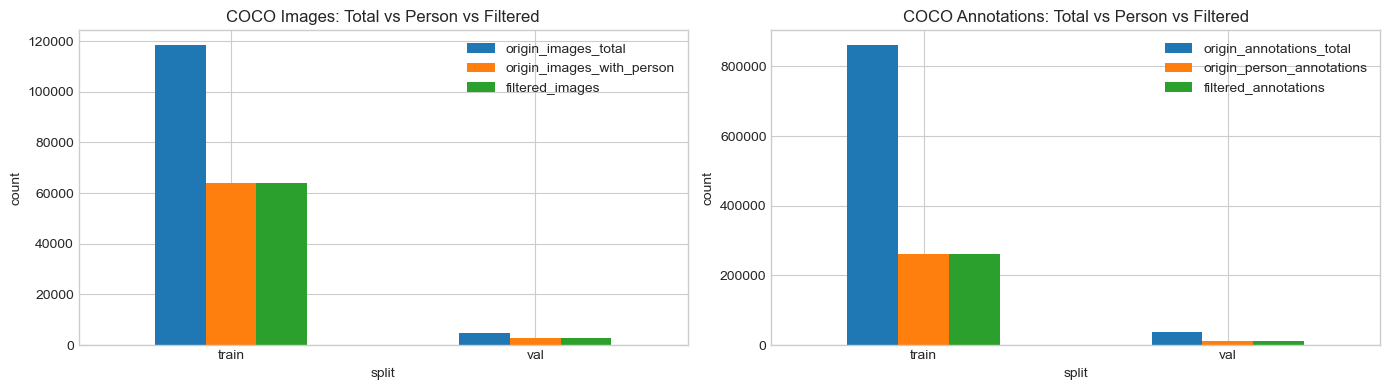

In [5]:

# COCO retention: compare origin vs filtered for train/val
rows = []
for b_split, a_split in [("train", "train"), ("validation", "val")]:
    b = coco_before_df[coco_before_df["split"] == b_split].iloc[0]
    a = coco_after_df[coco_after_df["split"] == a_split].iloc[0]
    rows.append(
        {
            "split": split_key(b_split),
            "origin_images_total": int(b["num_images"]),
            "origin_images_with_person": int(b["images_with_person"]),
            "filtered_images": int(a["num_images"]),
            "origin_annotations_total": int(b["num_annotations"]),
            "origin_person_annotations": int(b["person_annotations"]),
            "filtered_annotations": int(a["num_annotations"]),
            "img_retention_vs_total": safe_div(int(a["num_images"]), int(b["num_images"])),
            "img_retention_vs_person_images": safe_div(int(a["num_images"]), int(b["images_with_person"])),
            "ann_retention_vs_total": safe_div(int(a["num_annotations"]), int(b["num_annotations"])),
            "ann_retention_vs_person_anns": safe_div(int(a["num_annotations"]), int(b["person_annotations"])),
        }
    )

coco_retention_df = pd.DataFrame(rows)
display(coco_retention_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_df = coco_retention_df.set_index("split")

plot_df[["origin_images_total", "origin_images_with_person", "filtered_images"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("COCO Images: Total vs Person vs Filtered")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

plot_df[["origin_annotations_total", "origin_person_annotations", "filtered_annotations"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("COCO Annotations: Total vs Person vs Filtered")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


,category_id,count,category_name
0,1,262465,person
1,3,43867,car
2,62,38491,chair
3,84,24715,book
4,44,24342,bottle
5,47,20650,cup
6,67,15714,dining table
7,51,14358,bowl
8,10,12884,traffic light
9,31,12354,handbag


,category_id,count,category_name
0,1,11004,person
1,3,1932,car
2,62,1791,chair
3,84,1161,book
4,44,1025,bottle
5,47,899,cup
6,67,697,dining table
7,10,637,traffic light
8,51,626,bowl
9,31,540,handbag


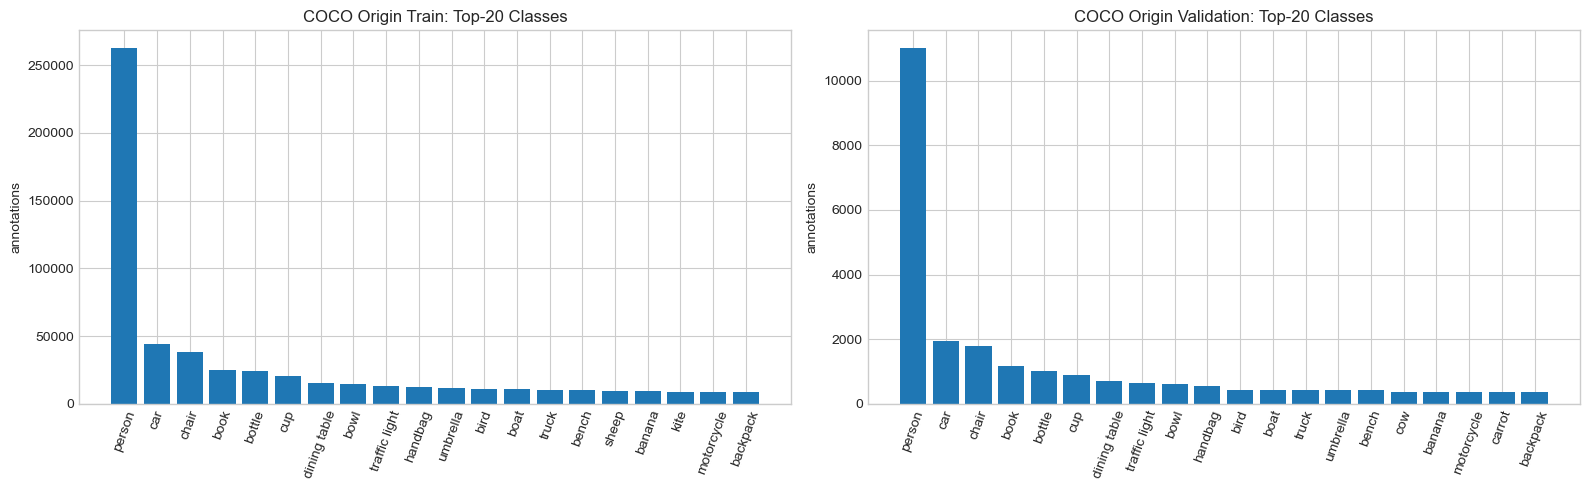

In [6]:

# COCO before-extraction class distribution (top-20)
origin_train_class_counts = coco_class_counts(coco_origin["train"]).head(20)
origin_val_class_counts = coco_class_counts(coco_origin["validation"]).head(20)

display(origin_train_class_counts)

display(origin_val_class_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(origin_train_class_counts["category_name"], origin_train_class_counts["count"])
axes[0].set_title("COCO Origin Train: Top-20 Classes")
axes[0].set_ylabel("annotations")
axes[0].tick_params(axis="x", rotation=70)

axes[1].bar(origin_val_class_counts["category_name"], origin_val_class_counts["count"])
axes[1].set_title("COCO Origin Validation: Top-20 Classes")
axes[1].set_ylabel("annotations")
axes[1].tick_params(axis="x", rotation=70)

plt.tight_layout()
plt.show()


In [7]:

KITTI_CLASS_MAP = {
    0: "car",
    1: "van",
    2: "truck",
    3: "pedestrian",
    4: "Person_sitting",
    5: "cyclist",
    6: "tram",
    7: "misc",
}
PERSON_LIKE_IDS = {3, 4, 5}


def count_images(images_dir: Path) -> int:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(1 for p in images_dir.glob("*") if p.is_file() and p.suffix.lower() in exts)


def parse_kitti_yolo_split(label_dir: Path, split_label: str, class_map: dict) -> tuple[pd.DataFrame, int]:
    records = []
    label_files = sorted(label_dir.glob("*.txt"))
    for fp in label_files:
        stem = fp.stem
        text = fp.read_text(encoding="utf-8", errors="ignore")
        for line in text.splitlines():
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            try:
                cid = int(float(parts[0]))
                xc, yc, w, h = map(float, parts[1:5])
            except ValueError:
                continue

            records.append(
                {
                    "split": split_label,
                    "image_stem": stem,
                    "class_id": cid,
                    "class_name": class_map.get(cid, f"class_{cid}"),
                    "x_center": xc,
                    "y_center": yc,
                    "bbox_w_norm": w,
                    "bbox_h_norm": h,
                    "area_ratio": w * h,
                    "aspect_ratio": safe_div(w, h),
                    "is_person_like": cid in PERSON_LIKE_IDS,
                }
            )

    df = pd.DataFrame(records)
    return df, len(label_files)


KITTI before summary


,dataset,split,num_images,num_label_files,num_annotations,person_category_ids,person_like_annotations,images_with_person_like
0,kitti-yolo,train,5985,5985,32442,"[3, 4, 5]",5027,1965
1,kitti-yolo,val,1496,1496,8128,"[3, 4, 5]",1309,536


KITTI after summary


,dataset,split,split_key,num_categories,num_images,num_annotations,person_category_ids,person_annotations,images_with_person
0,kitti-filtered-coco,train,train,1,1965,5027,[1],5027,1965
1,kitti-filtered-coco,val,val,1,536,1309,[1],1309,536


,split,before_images_total,before_images_with_person_like,after_images,before_person_like_annotations,after_annotations,img_retention_vs_person_images,ann_retention_vs_person_like_anns
0,train,5985,1965,1965,5027,5027,1.0,1.0
1,val,1496,536,536,1309,1309,1.0,1.0


,class_id,class_name,count
0,0,car,28742
3,3,pedestrian,4487
1,1,van,2914
5,5,cyclist,1627
2,2,truck,1094
7,7,misc,973
6,6,tram,511
4,4,Person_sitting,222


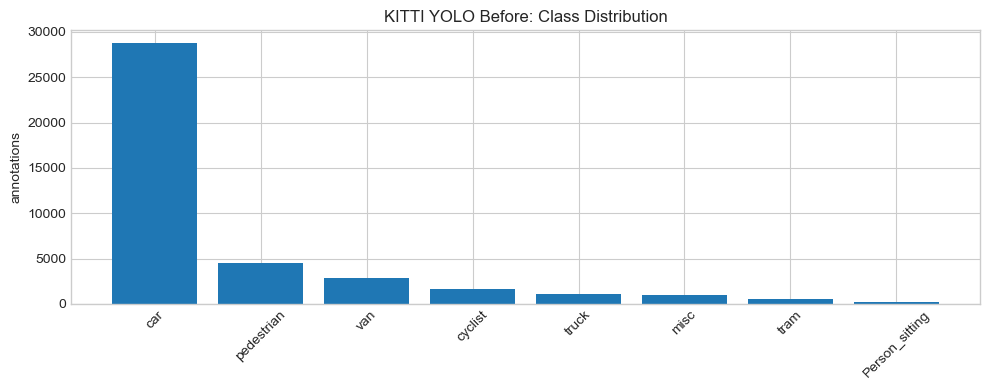

In [8]:

# KITTI before (YOLO)
kitti_before_parts = {}
kitti_before_label_files = {}
for split in ["train", "val"]:
    df, n_files = parse_kitti_yolo_split(KITTI_YOLO_ROOT / "labels" / split, split, KITTI_CLASS_MAP)
    kitti_before_parts[split] = df
    kitti_before_label_files[split] = n_files

kitti_before_df = pd.concat([kitti_before_parts["train"], kitti_before_parts["val"]], ignore_index=True)

before_rows = []
for split in ["train", "val"]:
    df = kitti_before_parts[split]
    total_images = count_images(KITTI_YOLO_ROOT / "images" / split)
    person_like = df[df["is_person_like"]]
    before_rows.append(
        {
            "dataset": "kitti-yolo",
            "split": split,
            "num_images": total_images,
            "num_label_files": kitti_before_label_files[split],
            "num_annotations": int(len(df)),
            "person_category_ids": list(PERSON_LIKE_IDS),
            "person_like_annotations": int(len(person_like)),
            "images_with_person_like": int(person_like["image_stem"].nunique()),
        }
    )
kitti_before_summary = pd.DataFrame(before_rows)
print("KITTI before summary")
display(kitti_before_summary)

# KITTI after (filtered COCO)
kitti_after = {split: load_coco(path) for split, path in KITTI_FILTERED_ANN.items()}
kitti_after_summary = pd.DataFrame(
    [coco_split_summary(kitti_after[s], "kitti-filtered-coco", s, person_name="person") for s in ["train", "val"]]
)
print("KITTI after summary")
display(kitti_after_summary)

# Retention comparison
rows = []
for split in ["train", "val"]:
    b = kitti_before_summary[kitti_before_summary["split"] == split].iloc[0]
    a = kitti_after_summary[kitti_after_summary["split"] == split].iloc[0]
    rows.append(
        {
            "split": split,
            "before_images_total": int(b["num_images"]),
            "before_images_with_person_like": int(b["images_with_person_like"]),
            "after_images": int(a["num_images"]),
            "before_person_like_annotations": int(b["person_like_annotations"]),
            "after_annotations": int(a["num_annotations"]),
            "img_retention_vs_person_images": safe_div(int(a["num_images"]), int(b["images_with_person_like"])),
            "ann_retention_vs_person_like_anns": safe_div(int(a["num_annotations"]), int(b["person_like_annotations"])),
        }
    )

kitti_retention_df = pd.DataFrame(rows)
display(kitti_retention_df)

# KITTI before class distribution
kitti_class_counts = (
    kitti_before_df.groupby(["class_id", "class_name"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
)
display(kitti_class_counts)

plt.figure(figsize=(10, 4))
plt.bar(kitti_class_counts["class_name"], kitti_class_counts["count"])
plt.title("KITTI YOLO Before: Class Distribution")
plt.ylabel("annotations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Notes

- `coco2017-origin/test/labels.json` has no `annotations` (COCO test split), so person-filter metrics are only meaningful for train/validation.
- For KITTI before filtering, person-like classes are treated as IDs `{3, 4, 5}` from `kitti.yaml`:
  - `3: pedestrian`
  - `4: Person_sitting`
  - `5: cyclist`
- To compare geometry between YOLO and COCO fairly, this notebook uses `area_ratio = bbox_area / image_area` and `aspect_ratio = bbox_w / bbox_h`.
